<a href="https://colab.research.google.com/github/YAshhh29/Algorithms/blob/main/ffNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  FEED FORWARD NEURAL NETWORK — CUSTOMER CHURN PREDICTION

[Step 1] Loading and Preprocessing Data...
  Dataset Shape: (64374, 12)

  First 3 rows:
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay Subscription Type Contract Length  Total Spend  Last Interaction  Churn
0           1   22  Female      25               14              4             27             Basic         Monthly          598                 9      1
1           2   41  Female      28               28              7             13          Standard         Monthly          584                20      0
2           3   47    Male      27               10              2             29           Premium          Annual          757                21      0

  Missing Values:
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Inter

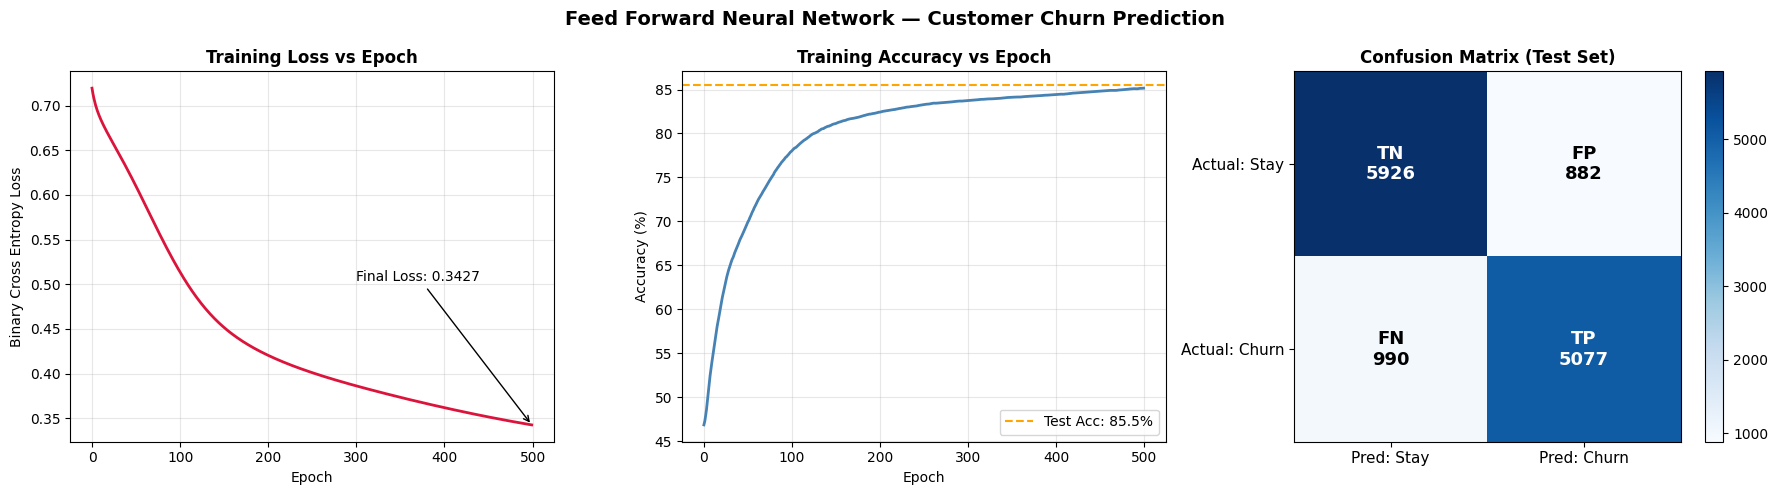


  [Saved] nn_results.png

  BUSINESS ANALYSIS

  1. Payment Delay vs Churn:
     Avg delay for Stay  customers : 12.5 days
     Avg delay for Churn customers : 22.3 days
     → Churners delay payment by 9.9 more days on average.

  2. Usage Frequency vs Churn:
     Avg usage for Stay  customers : 16.0x/month
     Avg usage for Churn customers : 14.0x/month

  3. Churn Rate by Subscription Type:
     Basic      : 48.3%
     Premium    : 46.5%
     Standard   : 47.3%

  4. Tenure vs Churn:
     Avg tenure for Stay  customers : 28.8 months
     Avg tenure for Churn customers : 35.5 months

  5. Support Calls vs Churn:
     Avg calls for Stay  customers : 4.5
     Avg calls for Churn customers : 6.4

  Business Recommendations:
  ─────────────────────────────────────────────────
  • Target retention offers to customers with high payment delay
  • Re-engage customers with declining usage frequency
  • Offer upgrade incentives to Basic plan subscribers
  • Focus on customers in their first 

In [3]:
# ================================================================
#  FEED FORWARD NEURAL NETWORK FROM SCRATCH
#  Application: Customer Churn Prediction
#  For: AIML Lab - Google Colab
#  Restrictions: Only numpy, pandas, matplotlib allowed
# ================================================================
#
# HOW TO RUN ON GOOGLE COLAB:
#   1. Upload this file and the CSV to Colab (Files panel on left)
#   2. Runtime > Run All
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# ██████╗ ██████╗ ███████╗██████╗ ██████╗  ██████╗  ██████╗
# ██╔══██╗██╔══██╗██╔════╝██╔══██╗██╔══██╗██╔═══██╗██╔════╝
# ██████╔╝██████╔╝█████╗  ██████╔╝██████╔╝██║   ██║██║
# ██╔═══╝ ██╔══██╗██╔══╝  ██╔═══╝ ██╔══██╗██║   ██║██║
# ██║     ██║  ██║███████╗██║     ██║  ██║╚██████╔╝╚██████╗
# ╚═╝     ╚═╝  ╚═╝╚══════╝╚═╝     ╚═╝  ╚═╝ ╚═════╝  ╚═════╝
# ================================================================
# TEACHING NOTES FOR TA:
#
# WHAT IS A NEURON?
# -----------------
# A single neuron is a mathematical unit that:
#   1. Takes multiple inputs (x1, x2, ..., xn)
#   2. Multiplies each by a weight  (w1, w2, ..., wn)
#   3. Adds a bias term (b)
#   4. Passes through an activation function f()
#
#   z = w1*x1 + w2*x2 + ... + wn*xn + b  ← linear combination
#   a = f(z)                               ← activation (adds non-linearity)
#
# WHY HIDDEN LAYERS?
# ------------------
# - A single layer can only learn LINEAR decision boundaries (a straight line)
# - Hidden layers let the network learn COMPLEX, NONLINEAR patterns
# - Layer 1: learns low-level patterns (e.g., "high payment delay?")
# - Layer 2: combines patterns (e.g., "high delay AND low usage?")
# - Output: final decision (Churn or Stay)
#
# ANALOGY FOR STUDENTS:
#   Think of it like a company decision:
#   - Junior analysts (Layer 1) look at individual signals
#   - Senior analysts (Layer 2) combine those signals
#   - Manager (Output) makes the final call
# ================================================================

print("=" * 60)
print("  FEED FORWARD NEURAL NETWORK — CUSTOMER CHURN PREDICTION")
print("=" * 60)


# ================================================================
# Qn-1: DATA PREPROCESSING
# ================================================================
# TEACHING NOTES:
# ---------------
# WHY normalize?
#   If Age is in range [18, 80] and Payment Delay is [0, 10],
#   the network will give more weight to Age just because its values
#   are larger — not because it's more important.
#   Normalization puts ALL features on the same scale (mean=0, std=1).
#
# WHY encode categorical?
#   Neural networks work with numbers only. "Male"/"Female" → 1/0
# ================================================================

print("\n[Step 1] Loading and Preprocessing Data...")

df = pd.read_csv('customer_churn_dataset-testing-master.csv')
print(f"  Dataset Shape: {df.shape}")
print(f"\n  First 3 rows:\n{df.head(3).to_string()}")

# Remove identifier column (not a feature)
df.drop('CustomerID', axis=1, inplace=True)

# Check for missing values
print(f"\n  Missing Values:\n{df.isnull().sum().to_string()}")

# --- Encode Categorical Variables ---
# One-to-one label encoding for ordinal/binary categories
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Subscription Type: ordinal encoding (Basic < Standard < Premium)
df['Subscription Type'] = df['Subscription Type'].map(
    {'Basic': 0, 'Standard': 1, 'Premium': 2}
)

# Contract Length: ordinal (shorter contract = higher churn risk typically)
df['Contract Length'] = df['Contract Length'].map(
    {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
)

# Target: already 0/1 in this dataset
df['Churn'] = df['Churn'].astype(int)

# Separate features and target
X = df.drop('Churn', axis=1).values.astype(float)
y = df['Churn'].values.reshape(-1, 1).astype(float)

# --- Normalize ALL numerical features (Z-score normalization) ---
# Formula: x_normalized = (x - mean) / std
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_std[X_std == 0] = 1  # avoid division by zero for constant features
X = (X - X_mean) / X_std

print(f"\n  Feature matrix shape : {X.shape}")
print(f"  Target vector shape  : {y.shape}")
print(f"  Churn rate           : {y.mean()*100:.1f}%")

feature_names = ['Age', 'Gender', 'Tenure', 'Usage Frequency',
                 'Support Calls', 'Payment Delay', 'Subscription Type',
                 'Contract Length', 'Total Spend', 'Last Interaction']
print(f"\n  Features used: {feature_names}")


# ================================================================
# Qn-2: TRAIN-TEST SPLIT (Custom — no sklearn)
# ================================================================
# TEACHING NOTES:
# ---------------
# We shuffle indices randomly before splitting so that training/test
# sets are representative of the full data (not biased by ordering).
# 80% train = model learns from this
# 20% test  = model evaluated on unseen data (honest evaluation)
# ================================================================

def train_test_split_custom(X, y, test_size=0.2, random_seed=42):
    """Custom train-test split without sklearn."""
    np.random.seed(random_seed)
    indices = np.random.permutation(len(X))     # shuffle indices
    split_point = int(len(X) * (1 - test_size)) # 80% boundary
    train_idx = indices[:split_point]
    test_idx  = indices[split_point:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_custom(X, y)

print(f"\n[Step 2] Train-Test Split")
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")


# ================================================================
# ACTIVATION FUNCTIONS
# ================================================================
# TEACHING NOTES:
# ---------------
# WHY activation functions?
#   Without them, stacking many layers is mathematically equivalent
#   to just ONE linear layer → useless depth!
#   Activation adds NON-LINEARITY, letting the network learn complex
#   decision boundaries.
#
# ReLU (Rectified Linear Unit): f(x) = max(0, x)
#   - Kills negative values (sets to 0)
#   - Keeps positive values unchanged
#   - Fast to compute, avoids "vanishing gradient" problem
#   - Used in HIDDEN layers
#
# Sigmoid: f(x) = 1 / (1 + e^-x)
#   - Squashes any value to (0, 1)
#   - Interpreted as PROBABILITY
#   - Used in OUTPUT layer for binary classification
#
# DRAW ON WHITEBOARD:
#   ReLU:   ___/         Sigmoid: _S_
#          /                     /
#   ______/              -------/
# ================================================================

def relu(x):
    """ReLU activation: max(0, x). Used in hidden layers."""
    return np.maximum(0, x)

def relu_derivative(x):
    """
    Derivative of ReLU:
      = 1 if x > 0
      = 0 if x <= 0
    This is used during backpropagation.
    """
    return (x > 0).astype(float)

def sigmoid(x):
    """
    Sigmoid activation: 1 / (1 + e^-x)
    Clips input to avoid numerical overflow.
    Used in output layer → gives probability of churn.
    """
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


# ================================================================
# Qn-3: INITIALIZE PARAMETERS
# ================================================================
# TEACHING NOTES:
# ---------------
# WHY random initialization?
#   If all weights start at 0, every neuron computes the SAME thing
#   during forward pass, and gets the SAME gradient during backprop.
#   The network never "differentiates" → called the symmetry problem.
#
# WHY multiply by 0.01?
#   Start with SMALL random weights so that:
#   - sigmoid/relu inputs stay near zero (good gradient flow)
#   - training starts in a stable region
#
# WEIGHT MATRIX SHAPES (crucial for matrix multiplication):
#   W1: (input_size, 12)  — each of 12 neurons has input_size weights
#   W2: (12, 6)           — each of 6 neurons gets 12 inputs
#   W3: (6, 1)            — single output neuron gets 6 inputs
#
# BIAS SHAPES:
#   b1: (1, 12)  — one bias per neuron in layer 1
#   b2: (1, 6)
#   b3: (1, 1)
# ================================================================

def initialize_parameters(n_input, n_h1, n_h2, n_out):
    """
    Randomly initialize weights and zero-initialize biases.

    Parameters:
        n_input : number of input features
        n_h1    : neurons in hidden layer 1
        n_h2    : neurons in hidden layer 2
        n_out   : neurons in output layer (1 for binary classification)

    Returns:
        dict of W1, b1, W2, b2, W3, b3
    """
    np.random.seed(42)
    # He initialization: sqrt(2/fan_in), designed for ReLU networks
    params = {
        'W1': np.random.randn(n_input, n_h1) * np.sqrt(2.0 / n_input),
        'b1': np.zeros((1, n_h1)),                      # (1, 12)
        'W2': np.random.randn(n_h1, n_h2) * np.sqrt(2.0 / n_h1),
        'b2': np.zeros((1, n_h2)),                      # (1, 6)
        'W3': np.random.randn(n_h2, n_out) * np.sqrt(2.0 / n_h2),
        'b3': np.zeros((1, n_out))                      # (1, 1)
    }
    return params

INPUT_SIZE   = X_train.shape[1]   # 10 features
HIDDEN1_SIZE = 12
HIDDEN2_SIZE = 6
OUTPUT_SIZE  = 1

params = initialize_parameters(INPUT_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE)

print(f"\n[Step 3] Network Architecture Initialized")
print(f"  Input Layer    : {INPUT_SIZE} neurons")
print(f"  Hidden Layer 1 : {HIDDEN1_SIZE} neurons  [ReLU]")
print(f"  Hidden Layer 2 : {HIDDEN2_SIZE} neurons   [ReLU]")
print(f"  Output Layer   : {OUTPUT_SIZE} neuron    [Sigmoid]")
print(f"\n  Weight Shapes:")
for k, v in params.items():
    print(f"    {k}: {v.shape}")


# ================================================================
# Qn-4: FORWARD PROPAGATION
# ================================================================
# TEACHING NOTES:
# ---------------
# This is the "prediction" step. Data flows LEFT → RIGHT through the
# network. Each layer transforms the data.
#
# STEP BY STEP (draw this on the board):
#
#  X (n,10) ──[W1,b1]──> Z1 (n,12) ──[ReLU]──> A1 (n,12)
#                                                    │
#                              A1 ──[W2,b2]──> Z2 (n,6) ──[ReLU]──> A2 (n,6)
#                                                                         │
#                                                 A2 ──[W3,b3]──> Z3 (n,1) ──[Sigmoid]──> y_hat (n,1)
#
# MATRIX MULTIPLICATION INTUITION:
#   X has shape (n_samples, n_features)
#   W1 has shape (n_features, 12)
#   X @ W1 = Z1 with shape (n_samples, 12)
#   → Every sample gets 12 values, one per hidden neuron
#
# The "cache" stores intermediate values we'll need in backpropagation.
# ================================================================

def forward_propagation(X, params):
    """
    Perform forward pass through the network.

    Returns:
        y_hat : predicted probabilities (n, 1)
        cache : dict of Z1, A1, Z2, A2, Z3, y_hat for backprop
    """
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    W3, b3 = params['W3'], params['b3']

    # --- Layer 1 ---
    Z1 = np.dot(X, W1) + b1   # Linear transform: (n, 12)
    A1 = relu(Z1)              # Apply ReLU:       (n, 12)

    # --- Layer 2 ---
    Z2 = np.dot(A1, W2) + b2  # Linear transform: (n, 6)
    A2 = relu(Z2)              # Apply ReLU:       (n, 6)

    # --- Output Layer ---
    Z3   = np.dot(A2, W3) + b3  # Linear transform:   (n, 1)
    y_hat = sigmoid(Z3)          # Sigmoid → prob of churn (n, 1)

    cache = {
        'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3, 'y_hat': y_hat
    }
    return y_hat, cache


# ================================================================
# Qn-5: LOSS FUNCTION — Binary Cross Entropy
# ================================================================
# TEACHING NOTES:
# ---------------
# WHY not just use accuracy as the loss?
#   Accuracy is not differentiable — we can't take its gradient!
#   We need a smooth function to compute gradients.
#
# Binary Cross Entropy (BCE):
#   Loss = -(1/n) * Σ [ y*log(ŷ) + (1-y)*log(1-ŷ) ]
#
#   Case 1: True label y=1 (Churn)
#     Loss = -log(ŷ)
#     → If ŷ → 1 (correct): -log(1) = 0   (no loss)
#     → If ŷ → 0 (wrong):   -log(0) = ∞   (huge penalty!)
#
#   Case 2: True label y=0 (Stay)
#     Loss = -log(1-ŷ)
#     → If ŷ → 0 (correct): -log(1) = 0   (no loss)
#     → If ŷ → 1 (wrong):   -log(0) = ∞   (huge penalty!)
#
#   The 1e-8 is added to avoid log(0) = -infinity (numerical stability)
# ================================================================

def compute_loss(y_true, y_hat):
    """
    Binary Cross Entropy loss.

    Args:
        y_true : actual labels (n, 1)
        y_hat  : predicted probabilities (n, 1)

    Returns:
        scalar loss value
    """
    eps  = 1e-8  # small constant for numerical stability
    loss = -np.mean(
        y_true * np.log(y_hat + eps) +
        (1 - y_true) * np.log(1 - y_hat + eps)
    )
    return loss


# ================================================================
# Qn-6: BACKPROPAGATION
# ================================================================
# TEACHING NOTES:
# ---------------
# This is the HEART of neural network training. It's the algorithm
# that tells each weight: "you need to go up/down by this much."
#
# CORE IDEA: Chain Rule from calculus
#   If Loss depends on W3 through y_hat, which depends on Z3:
#   ∂Loss/∂W3 = (∂Loss/∂y_hat) · (∂y_hat/∂Z3) · (∂Z3/∂W3)
#
# INTUITION (analogy for students):
#   Imagine you're baking bread and it came out too dense.
#   - Was it the flour? (W1)
#   - The yeast? (W2)
#   - The baking time? (W3)
#   Backprop is like tracing back through each step to find WHO
#   is most responsible for the bad outcome, then adjusting each.
#
# GRADIENT FLOW (right to left):
#
#  ∂L/∂Z3 = y_hat - y_true        ← output layer gradient (super clean!)
#     ↓
#  ∂L/∂W3 = A2ᵀ · dZ3 / n
#  ∂L/∂b3 = mean(dZ3)
#     ↓
#  ∂L/∂A2 = dZ3 · W3ᵀ             ← propagate error back
#  ∂L/∂Z2 = dA2 · ReLU'(Z2)       ← gate through ReLU derivative
#  ∂L/∂W2 = A1ᵀ · dZ2 / n
#  ∂L/∂b2 = mean(dZ2)
#     ↓
#  ∂L/∂A1 = dZ2 · W2ᵀ
#  ∂L/∂Z1 = dA1 · ReLU'(Z1)
#  ∂L/∂W1 = Xᵀ · dZ1 / n
#  ∂L/∂b1 = mean(dZ1)
#
# KEY INSIGHT on ReLU derivative:
#   ReLU'(z) = 1 if z > 0, else 0
#   This GATES the gradient: if a neuron was off (z≤0), its gradient
#   is 0 — that neuron doesn't learn from this example. This is
#   why it's called a "gate" — it either passes or blocks gradient flow.
# ================================================================

def backpropagation(X, y_true, params, cache):
    """
    Compute gradients using backpropagation.

    Returns:
        grads : dict of dW1, db1, dW2, db2, dW3, db3
    """
    n   = X.shape[0]
    W2  = params['W2']
    W3  = params['W3']

    Z1, A1 = cache['Z1'], cache['A1']
    Z2, A2 = cache['Z2'], cache['A2']
    y_hat  = cache['y_hat']

    # ── Output Layer ────────────────────────────────────
    # dL/dZ3 = y_hat - y_true  (combined gradient of BCE + sigmoid)
    dZ3 = y_hat - y_true                          # (n, 1)
    dW3 = np.dot(A2.T, dZ3) / n                  # (6, 1)
    db3 = np.mean(dZ3, axis=0, keepdims=True)     # (1, 1)

    # ── Hidden Layer 2 ───────────────────────────────────
    dA2 = np.dot(dZ3, W3.T)                       # (n, 6)  ← propagate error back
    dZ2 = dA2 * relu_derivative(Z2)               # (n, 6)  ← gate through ReLU'
    dW2 = np.dot(A1.T, dZ2) / n                   # (12, 6)
    db2 = np.mean(dZ2, axis=0, keepdims=True)     # (1, 6)

    # ── Hidden Layer 1 ───────────────────────────────────
    dA1 = np.dot(dZ2, W2.T)                       # (n, 12)
    dZ1 = dA1 * relu_derivative(Z1)               # (n, 12)
    dW1 = np.dot(X.T, dZ1) / n                    # (10, 12)
    db1 = np.mean(dZ1, axis=0, keepdims=True)     # (1, 12)

    grads = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }
    return grads


# ================================================================
# UPDATE PARAMETERS — Gradient Descent
# ================================================================
# TEACHING NOTES:
# ---------------
# Gradient Descent update rule:
#   W = W - α * ∂L/∂W
#   b = b - α * ∂L/∂b
#
# Where α (alpha) = learning rate
#
# ANALOGY: You're blindfolded on a hilly terrain trying to reach
# the lowest valley (minimum loss). The gradient tells you which
# direction is "uphill". You step in the OPPOSITE direction.
#
# learning_rate = how big a step to take:
#   Too large → overshoot, loss diverges (like a drunk person)
#   Too small → takes forever to converge
#   0.01 is usually a safe starting point
# ================================================================

def update_parameters(params, grads, learning_rate):
    """Apply gradient descent update to all parameters."""
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    params['W3'] -= learning_rate * grads['dW3']
    params['b3'] -= learning_rate * grads['db3']
    return params


# ================================================================
# Qn-8: PREDICTION
# ================================================================
# TEACHING NOTES:
# ---------------
# The sigmoid output gives a PROBABILITY, not a class label.
# We apply a threshold of 0.5:
#   ŷ ≥ 0.5 → Churn (1)
#   ŷ <  0.5 → Stay  (0)
#
# This threshold can be adjusted! If the business cares more about
# catching all churners (recall), lower it to 0.3. If they care
# about not spamming non-churners with offers (precision), raise it.
# ================================================================

def predict(X, params):
    """Run forward pass and apply 0.5 threshold for class prediction."""
    y_hat, _ = forward_propagation(X, params)
    return (y_hat >= 0.5).astype(int)


# ================================================================
# Qn-9: EVALUATION METRICS
# ================================================================
# TEACHING NOTES:
# ---------------
# Why not just use accuracy?
#   If 90% customers Stay, a model that always predicts "Stay" gets
#   90% accuracy — but it's completely useless for finding churners!
#
# CONFUSION MATRIX (draw this on board):
#
#                  Predicted Stay | Predicted Churn
#   Actual Stay  :      TN        |      FP
#   Actual Churn :      FN        |      TP
#
# Precision = TP / (TP + FP)
#   → Of all predicted churners, how many actually churned?
#   → "Don't waste retention offers on the wrong people"
#
# Recall = TP / (TP + FN)
#   → Of all actual churners, how many did we catch?
#   → "Don't miss churners who will leave"
#
# F1-Score = 2 * P * R / (P + R)
#   → Harmonic mean of Precision and Recall
#   → Use when you want balance between the two
#
# In churn prediction, RECALL is usually more important:
#   Missing a churner (FN) is more costly than a false alarm (FP).
# ================================================================

def accuracy_score(y_true, y_pred):
    return np.mean(y_true.flatten() == y_pred.flatten()) * 100

def compute_metrics(y_true, y_pred):
    """Compute accuracy, precision, recall, F1, and confusion matrix."""
    y_t = y_true.flatten().astype(int)
    y_p = y_pred.flatten().astype(int)

    TP = int(np.sum((y_p == 1) & (y_t == 1)))
    TN = int(np.sum((y_p == 0) & (y_t == 0)))
    FP = int(np.sum((y_p == 1) & (y_t == 0)))
    FN = int(np.sum((y_p == 0) & (y_t == 1)))

    accuracy  = (TP + TN) / len(y_t) * 100
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    confusion = np.array([[TN, FP], [FN, TP]])
    return accuracy, precision, recall, f1, confusion, TP, TN, FP, FN


# ================================================================
# Qn-7: TRAINING LOOP
# ================================================================
# TEACHING NOTES:
# ---------------
# One EPOCH = one full pass through all training data
# 500 epochs = the network sees the data 500 times, improving each time
#
# TRAINING LOOP for each epoch:
#   1. Forward propagation → get predictions ŷ
#   2. Compute loss L(y, ŷ)
#   3. Backpropagation → compute gradients
#   4. Update parameters → W = W - α * dW
#   5. Track loss (should decrease over time)
#
# As loss decreases, accuracy should increase.
# ================================================================

EPOCHS        = 500
LEARNING_RATE = 0.1   # higher LR works better with He initialization
PRINT_EVERY   = 50

# Re-initialize fresh params
params = initialize_parameters(INPUT_SIZE, HIDDEN1_SIZE, HIDDEN2_SIZE, OUTPUT_SIZE)

losses           = []
train_accuracies = []

print("\n[Step 7] Training the Neural Network")
print(f"  Epochs: {EPOCHS} | Learning Rate: {LEARNING_RATE}")
print("-" * 55)
print(f"  {'Epoch':>6} | {'Loss':>10} | {'Train Accuracy':>15}")
print("-" * 55)

for epoch in range(EPOCHS):

    # 1. Forward Propagation
    y_hat, cache = forward_propagation(X_train, params)

    # 2. Compute Loss
    loss = compute_loss(y_train, y_hat)
    losses.append(loss)

    # 3. Backpropagation
    grads = backpropagation(X_train, y_train, params, cache)

    # 4. Update Parameters
    params = update_parameters(params, grads, LEARNING_RATE)

    # 5. Track Accuracy
    y_pred_train = (y_hat >= 0.5).astype(int)
    acc = accuracy_score(y_train, y_pred_train)
    train_accuracies.append(acc)

    if epoch % PRINT_EVERY == 0:
        print(f"  {epoch:>6} | {loss:>10.4f} | {acc:>14.2f}%")

print("-" * 55)
print("  Training Complete!")


# ================================================================
# FINAL EVALUATION ON TEST SET
# ================================================================

y_pred_test = predict(X_test, params)
accuracy, precision, recall, f1, confusion, TP, TN, FP, FN = compute_metrics(y_test, y_pred_test)

print("\n" + "=" * 55)
print("  TEST SET PERFORMANCE")
print("=" * 55)
print(f"  Accuracy  : {accuracy:.2f}%")
print(f"  Precision : {precision:.4f}  (of predicted churners, {precision*100:.1f}% were right)")
print(f"  Recall    : {recall:.4f}  (caught {recall*100:.1f}% of all actual churners)")
print(f"  F1-Score  : {f1:.4f}")
print("\n  Confusion Matrix:")
print("                  Pred Stay | Pred Churn")
print(f"  Actual Stay  :   {TN:6d}   |   {FP:6d}")
print(f"  Actual Churn :   {FN:6d}   |   {TP:6d}")
print("=" * 55)


# ================================================================
# Qn-10: VISUALIZATION
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feed Forward Neural Network — Customer Churn Prediction',
             fontsize=14, fontweight='bold')

# --- Plot 1: Training Loss Curve ---
axes[0].plot(losses, color='crimson', linewidth=2)
axes[0].set_title('Training Loss vs Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross Entropy Loss')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Final Loss: {losses[-1]:.4f}',
                  xy=(EPOCHS-1, losses[-1]),
                  xytext=(EPOCHS*0.6, losses[0]*0.7),
                  arrowprops=dict(arrowstyle='->', color='black'),
                  fontsize=10)

# --- Plot 2: Training Accuracy Curve ---
axes[1].plot(train_accuracies, color='steelblue', linewidth=2)
axes[1].set_title('Training Accuracy vs Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].axhline(y=accuracy, color='orange', linestyle='--',
                label=f'Test Acc: {accuracy:.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Confusion Matrix ---
cm_display = axes[2].imshow(confusion, interpolation='nearest',
                             cmap='Blues', aspect='auto')
plt.colorbar(cm_display, ax=axes[2])
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred: Stay', 'Pred: Churn'], fontsize=11)
axes[2].set_yticklabels(['Actual: Stay', 'Actual: Churn'], fontsize=11)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')

labels = [[f'TN\n{TN}', f'FP\n{FP}'],
          [f'FN\n{FN}', f'TP\n{TP}']]
thresh = confusion.max() / 2.0
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, labels[i][j],
                     ha='center', va='center', fontsize=13,
                     fontweight='bold',
                     color='white' if confusion[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('nn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  [Saved] nn_results.png")


# ================================================================
# Qn-11: BUSINESS ANALYSIS
# ================================================================
# Re-load original (un-normalized) data for interpretable analysis

df_orig = pd.read_csv('customer_churn_dataset-testing-master.csv')

print("\n" + "=" * 60)
print("  BUSINESS ANALYSIS")
print("=" * 60)

# Q1: Does higher payment delay increase churn?
avg_delay = df_orig.groupby('Churn')['Payment Delay'].mean()
print(f"\n  1. Payment Delay vs Churn:")
print(f"     Avg delay for Stay  customers : {avg_delay.get(0, 'N/A'):.1f} days")
print(f"     Avg delay for Churn customers : {avg_delay.get(1, 'N/A'):.1f} days")
diff = avg_delay.get(1, 0) - avg_delay.get(0, 0)
print(f"     → Churners delay payment by {abs(diff):.1f} more days on average.")

# Q2: Does low usage frequency relate to churn?
avg_usage = df_orig.groupby('Churn')['Usage Frequency'].mean()
print(f"\n  2. Usage Frequency vs Churn:")
print(f"     Avg usage for Stay  customers : {avg_usage.get(0, 'N/A'):.1f}x/month")
print(f"     Avg usage for Churn customers : {avg_usage.get(1, 'N/A'):.1f}x/month")

# Q3: Does subscription type affect retention?
sub_churn = df_orig.groupby('Subscription Type')['Churn'].mean() * 100
print(f"\n  3. Churn Rate by Subscription Type:")
for sub, rate in sub_churn.items():
    print(f"     {sub:10s} : {rate:.1f}%")

# Q4: Does shorter tenure indicate churn risk?
avg_tenure = df_orig.groupby('Churn')['Tenure'].mean()
print(f"\n  4. Tenure vs Churn:")
print(f"     Avg tenure for Stay  customers : {avg_tenure.get(0, 'N/A'):.1f} months")
print(f"     Avg tenure for Churn customers : {avg_tenure.get(1, 'N/A'):.1f} months")

# Q5: Support Calls vs Churn
avg_support = df_orig.groupby('Churn')['Support Calls'].mean()
print(f"\n  5. Support Calls vs Churn:")
print(f"     Avg calls for Stay  customers : {avg_support.get(0, 'N/A'):.1f}")
print(f"     Avg calls for Churn customers : {avg_support.get(1, 'N/A'):.1f}")

print("\n  Business Recommendations:")
print("  ─────────────────────────────────────────────────")
print("  • Target retention offers to customers with high payment delay")
print("  • Re-engage customers with declining usage frequency")
print("  • Offer upgrade incentives to Basic plan subscribers")
print("  • Focus on customers in their first year (low tenure)")
print("  • Flag customers with 5+ support calls for proactive outreach")
print("=" * 60)